# Experiment Analysis

Study  to find the most accurate and fastest parameter sets.

## 1. Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("results/experiments.csv")

# Fix sign issue: some runs discovered negative R — treat magnitude only
df["R_discovered"] = df["R_discovered"].abs()

# Recompute error with corrected R
df["R_error_pct"] = ((df["R_discovered"] - df["R_true"]).abs() / df["R_true"] * 100).round(4)

# Total epochs as a lightweight cost proxy when duration is unavailable
df["total_epochs"] = df["pinn_epochs"] + df["parameter_discovery_epochs"]

print(df[["exp_id", "R_error_pct", "pinn_final_loss", "total_epochs"]].to_string(index=False))


exp_id  R_error_pct  pinn_final_loss  total_epochs
  exp1      11.9091         0.223200         70000
  exp2      93.6084         0.178128         70000
  exp3       4.7413         0.245409         70000
  exp4      10.1043         0.208739         70000
  exp5       8.9799         0.223561         70000
  exp6       8.8827         0.328257         70000
  exp7      13.0273         0.354313         70000
  exp8       9.0144         0.353970         70000
  exp9       1.9949         0.335859         70000
 exp10       0.4030         0.232719         70000
 exp11       1.4572         0.343450         70000
 exp12       1.3247         0.220757         70000
 exp13       7.1323         0.356366         70000
 exp14      89.7177         2.163401         70000
 exp15       9.2530         2.483153         70000
 exp16       6.7411         2.478539         70000
 exp17       7.4678         3.399060         70000
 exp18      86.5324         3.622779         70000


## 2. Overview — all experiments

In [2]:
cols = [
    "exp_id",
    "parameter_discovery_collocation_points",
    "parameter_discovery_loss_2_weight",
    "parameter_discovery_epochs",
    "noise_coeff",
    "R_discovered", "R_error_pct", "pinn_final_loss", "total_epochs"
]
df[cols].sort_values("R_error_pct")


,exp_id,parameter_discovery_collocation_points,parameter_discovery_loss_2_weight,parameter_discovery_epochs,noise_coeff,R_discovered,R_error_pct,pinn_final_loss,total_epochs
9,exp10,1250,1.0,40000,2,0.004980,0.4030,0.232719,70000
11,exp12,1750,1.0,40000,2,0.005066,1.3247,0.220757,70000
10,exp11,1500,1.0,40000,2,0.004927,1.4572,0.343450,70000
8,exp9,10,1.0,40000,2,0.004900,1.9949,0.335859,70000
2,exp3,1000,0.5,40000,2,0.004763,4.7413,0.245409,70000
15,exp16,1000,1.0,40000,2,0.004663,6.7411,2.478539,70000
12,exp13,2000,1.0,40000,2,0.005357,7.1323,0.356366,70000
16,exp17,1000,1.0,40000,2,0.005373,7.4678,3.399060,70000
5,exp6,100,1.0,40000,2,0.005444,8.8827,0.328257,70000
4,exp5,1000,2.0,40000,2,0.004551,8.9799,0.223561,70000


In [3]:
# ── Drop duplicate parameter sets, keep the most accurate run ────────────────
param_cols = [
    "number_of_points", "noise_coeff",
    "pinn_collocation_points", "parameter_discovery_collocation_points",
    "pinn_loss2_weight", "parameter_discovery_loss_2_weight",
    "pinn_epochs", "parameter_discovery_epochs",
]

df = (
    df.sort_values("R_error_pct")           # best accuracy first
      .drop_duplicates(subset=param_cols)    # keep first (= best) of each duplicate group
      .reset_index(drop=True)
)

print(f"{len(df)} unique parameter sets remaining")
df[cols].sort_values("R_error_pct")

18 unique parameter sets remaining


,exp_id,parameter_discovery_collocation_points,parameter_discovery_loss_2_weight,parameter_discovery_epochs,noise_coeff,R_discovered,R_error_pct,pinn_final_loss,total_epochs
0,exp10,1250,1.0,40000,2,0.004980,0.4030,0.232719,70000
1,exp12,1750,1.0,40000,2,0.005066,1.3247,0.220757,70000
2,exp11,1500,1.0,40000,2,0.004927,1.4572,0.343450,70000
3,exp9,10,1.0,40000,2,0.004900,1.9949,0.335859,70000
4,exp3,1000,0.5,40000,2,0.004763,4.7413,0.245409,70000
5,exp16,1000,1.0,40000,2,0.004663,6.7411,2.478539,70000
6,exp13,2000,1.0,40000,2,0.005357,7.1323,0.356366,70000
7,exp17,1000,1.0,40000,2,0.005373,7.4678,3.399060,70000
8,exp6,100,1.0,40000,2,0.005444,8.8827,0.328257,70000
9,exp5,1000,2.0,40000,2,0.004551,8.9799,0.223561,70000


## 3. Most accurate runs

Lowest .

In [4]:
top_accurate = df.nsmallest(5, "R_error_pct")[cols]
print("Top 5 most accurate:")
top_accurate.head()


Top 5 most accurate:


,exp_id,parameter_discovery_collocation_points,parameter_discovery_loss_2_weight,parameter_discovery_epochs,noise_coeff,R_discovered,R_error_pct,pinn_final_loss,total_epochs
0,exp10,1250,1.0,40000,2,0.004980,0.4030,0.232719,70000
1,exp12,1750,1.0,40000,2,0.005066,1.3247,0.220757,70000
2,exp11,1500,1.0,40000,2,0.004927,1.4572,0.343450,70000
3,exp9,10,1.0,40000,2,0.004900,1.9949,0.335859,70000
4,exp3,1000,0.5,40000,2,0.004763,4.7413,0.245409,70000


## 4. Best accuracy vs speed

Runs with low error AND low total epochs — the sweet spot.

In [5]:
# Normalise both metrics to [0,1] then compute combined score (lower = better)
df["norm_error"]  = (df["R_error_pct"]  - df["R_error_pct"].min())  / (df["R_error_pct"].max()  - df["R_error_pct"].min() + 1e-9)
df["norm_epochs"] = (df["total_epochs"] - df["total_epochs"].min()) / (df["total_epochs"].max() - df["total_epochs"].min() + 1e-9)

# Equal weight — change 0.5/0.5 to bias toward accuracy or speed
df["combined_score"] = 0.5 * df["norm_error"] + 0.5 * df["norm_epochs"]

best = df.nsmallest(5, "combined_score")[["exp_id", "R_error_pct", "total_epochs", "combined_score"]]
print("Top 5 accuracy+speed:")
print(best.to_string(index=False))


Top 5 accuracy+speed:
exp_id  R_error_pct  total_epochs  combined_score
 exp10       0.4030         70000        0.000000
 exp12       1.3247         70000        0.004944
 exp11       1.4572         70000        0.005655
  exp9       1.9949         70000        0.008540
  exp3       4.7413         70000        0.023273


## 5. Plots

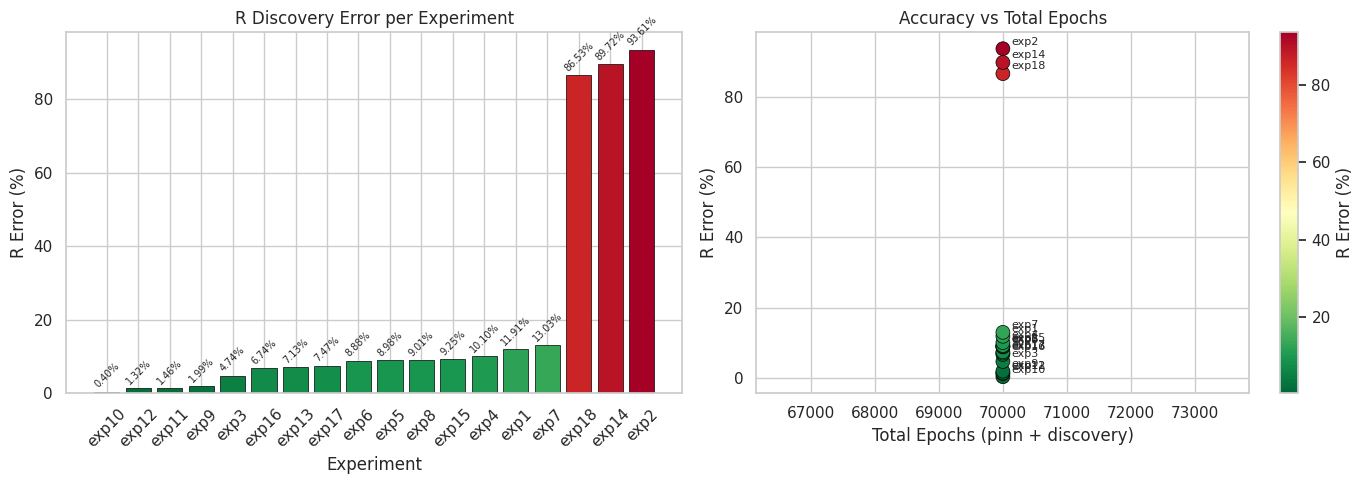

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — R error per exp —
ax = axes[0]
colors = cm.RdYlGn_r(df["R_error_pct"] / df["R_error_pct"].max())
bars = ax.bar(df["exp_id"], df["R_error_pct"], color=colors, edgecolor="black", lw=0.5)
for bar, v in zip(bars, df["R_error_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{v:.2f}%", ha="center", va="bottom", fontsize=7, rotation=45)
ax.set_title("R Discovery Error per Experiment")
ax.set_xlabel("Experiment")
ax.set_ylabel("R Error (%)")
ax.tick_params(axis="x", rotation=45)

# — Epochs vs error scatter —
ax = axes[1]
sc = ax.scatter(df["total_epochs"], df["R_error_pct"],
                c=df["R_error_pct"], cmap="RdYlGn_r", s=100, edgecolors="black", lw=0.5, zorder=3)
for _, row in df.iterrows():
    ax.annotate(row["exp_id"], (row["total_epochs"], row["R_error_pct"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)
fig.colorbar(sc, ax=ax, label="R Error (%)")
ax.set_title("Accuracy vs Total Epochs")
ax.set_xlabel("Total Epochs (pinn + discovery)")
ax.set_ylabel("R Error (%)")

plt.tight_layout()
plt.show()


## 6. How individual parameters affect accuracy

/home/reza/miniconda3/envs/pinns/lib/python3.10/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


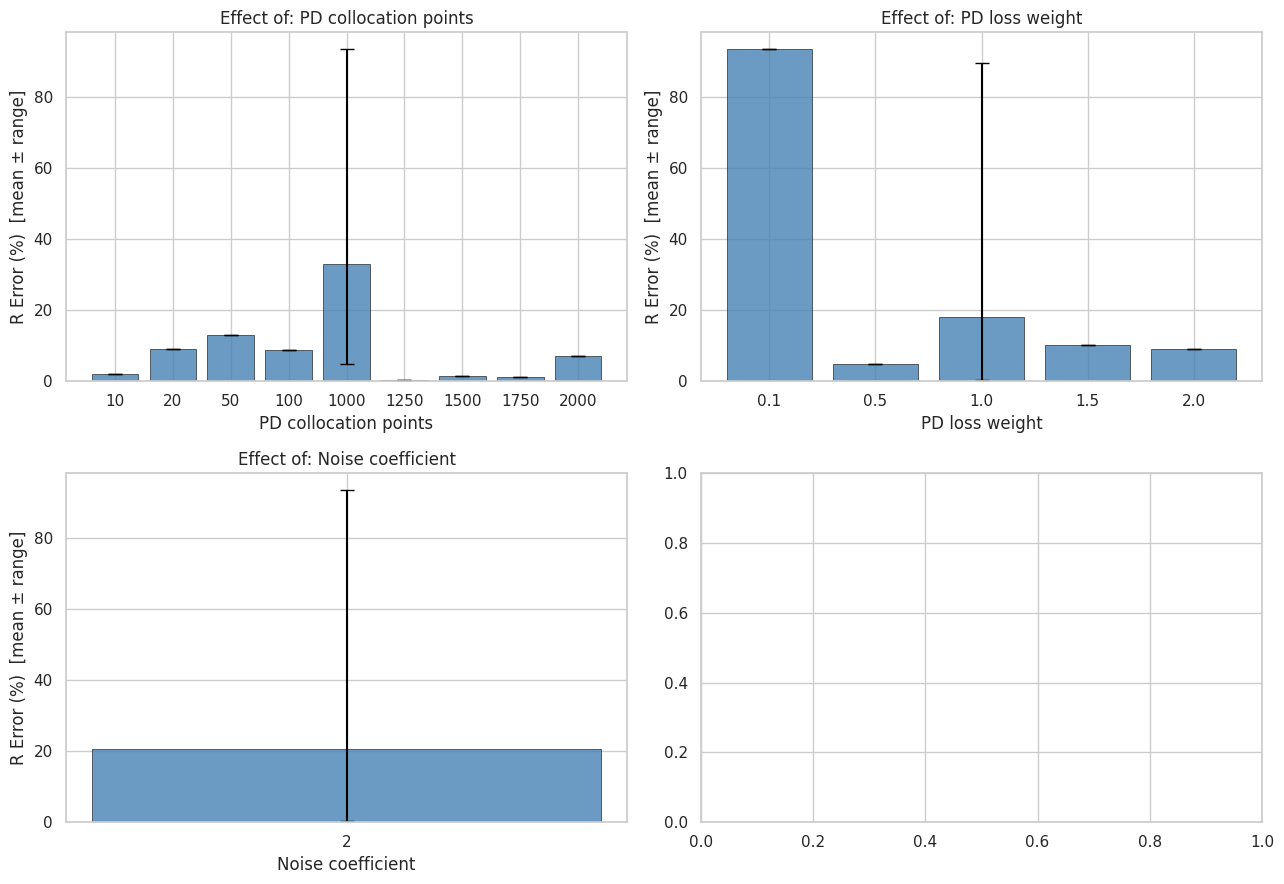

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

params_to_study = [
    ("parameter_discovery_collocation_points",  "PD collocation points"),
    ("parameter_discovery_loss_2_weight",       "PD loss weight"),
    ("noise_coeff",                             "Noise coefficient"),
]

for ax, (col, label) in zip(axes.flat, params_to_study):
    grouped = df.groupby(col)["R_error_pct"].agg(["mean", "min", "max"]).reset_index()
    x = grouped[col].astype(str)
    ax.bar(x, grouped["mean"], color="steelblue", alpha=0.8, label="mean", edgecolor="black", lw=0.5)
    ax.errorbar(x, grouped["mean"],
                yerr=[grouped["mean"] - grouped["min"], grouped["max"] - grouped["mean"]],
                fmt="none", color="black", capsize=5, lw=1.5)
    ax.set_title(f"Effect of: {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("R Error (%)  [mean ± range]")

plt.tight_layout()
plt.show()


## 7. Heatmap — collocation points × loss weight

## 8. Recommendation

Prints the single best config for accuracy, and the best balanced config.

In [8]:
best_accurate = df.loc[df["R_error_pct"].idxmin()]
best_balanced = df.loc[df["combined_score"].idxmin()]

param_cols = [
    "number_of_points", "noise_coeff",
    "pinn_collocation_points", "parameter_discovery_collocation_points",
    "pinn_loss2_weight", "parameter_discovery_loss_2_weight",
    "pinn_epochs", "parameter_discovery_epochs",
]

print("=" * 55)
print(f" BEST ACCURACY  →  {best_accurate['exp_id']}  |  R_error = {best_accurate['R_error_pct']:.4f}%")
print("=" * 55)
for c in param_cols:
    print(f"  {c:<48} {best_accurate[c]}")

print()
print("=" * 55)
print(f" BEST BALANCED  →  {best_balanced['exp_id']}  |  R_error = {best_balanced['R_error_pct']:.4f}%  |  total_epochs = {int(best_balanced['total_epochs'])}")
print("=" * 55)
for c in param_cols:
    print(f"  {c:<48} {best_balanced[c]}")


 BEST ACCURACY  →  exp10  |  R_error = 0.4030%
  number_of_points                                 10
  noise_coeff                                      2
  pinn_collocation_points                          1250
  parameter_discovery_collocation_points           1250
  pinn_loss2_weight                                1
  parameter_discovery_loss_2_weight                1.0
  pinn_epochs                                      30000
  parameter_discovery_epochs                       40000

 BEST BALANCED  →  exp10  |  R_error = 0.4030%  |  total_epochs = 70000
  number_of_points                                 10
  noise_coeff                                      2
  pinn_collocation_points                          1250
  parameter_discovery_collocation_points           1250
  pinn_loss2_weight                                1
  parameter_discovery_loss_2_weight                1.0
  pinn_epochs                                      30000
  parameter_discovery_epochs                       4000